## Neural Sorting

This project explores the concept of sorting using neural networks.


In [1]:
"""Shared Configurations across cells"""

SEED = 777
DATASET_SIZE = 10

## Loss function

The loss function compute the total entropy of a vector of numbers.
Entropy in this context must be interpreted as a measure of disorder, less the entropy, more ordered the vector is. The loss function is defined as follows:

`loss(x) = sum(|x_i - x_(i-1)|)
starting from i=1
`

Basically the loss function is the reduction sum of the absolute value of differences between each consecutive pair of elements in the vector.

## Loss validation (numerically)

A simple validation of the loss function can be done by computing the loss of a sorted vector and an unsorted vector `N` times, for `N` big enough we should think that the loss is correct. 

In [2]:
"""Unit Test for loss function"""

import numpy as np
from loss import disorder

SEED = 777
LENGTH_UPTO = 12
N = 1

rng = np.random.default_rng(SEED)

for length in range(2, LENGTH_UPTO):
    X = rng.standard_normal((N, length))
    loss_test_dataset = np.stack([X, np.sort(X)])
    loss_test_dataset = loss_test_dataset.swapaxes(0, 1)

    for i, (x, y) in enumerate(loss_test_dataset):
        random_disorder = round(disorder(x), 5)
        sorted_disorder = round(disorder(y), 5)

        try:
            assert sorted_disorder <= random_disorder
        except:
            print(f'iter={i}, lenght={length}')
            print(f"random disorder={disorder(x)}")
            print(f"sorted disorder={disorder(y)}")
            print('-----------------------------------------')
            print(f"random={x}")
            print(f"sorted={y}")
            break

## 3 Scenarios

### Scenario 1: Learn how to sort a specific permutation of the same vector
### Scenario 2: Learn how to sort a specific set of numbers
### Scenario 3: Learn how to generalize to arbitrary set of numbers

## Scenario 1: Learn how to sort a specific permutation of the same vector

The whole scenario consist in train the network to learn a specific permutation matrix that if applied to a specific vector, it will sort it. 

In [3]:
"""Model architecture"""

from thorcino.optimizer import SGD
from thorcino.training import CosineSchedule, Trainer
from thorcino.layers import Sequential, Linear
from loss import DisorderLoss

EPOCHS, EVAL_STEP = 20, 10
VECT_LENGTH = 5
MAX_LR, MIN_LR = 1e-3, 1e-6

model = Sequential(
    Linear(VECT_LENGTH, VECT_LENGTH)
)
loss = DisorderLoss()
optimizer = SGD(model.parameters, MAX_LR)
scheduler = CosineSchedule(MAX_LR, MIN_LR, EPOCHS)
trainer = Trainer(
    model,
    loss,
    optimizer,
    scheduler
)

In [4]:
from thorcino.tensor import Tensor

input = rng.standard_normal(VECT_LENGTH)
target = np.sort(input)
input, target = Tensor(input), Tensor(target)

tr_loss_history = []
for i in range(EPOCHS):
    pred = model(input)
    tr_loss = loss(pred, target)
    tr_loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    optimizer.lr = scheduler.get_lr(i)

    tr_loss_history.append(tr_loss.data)

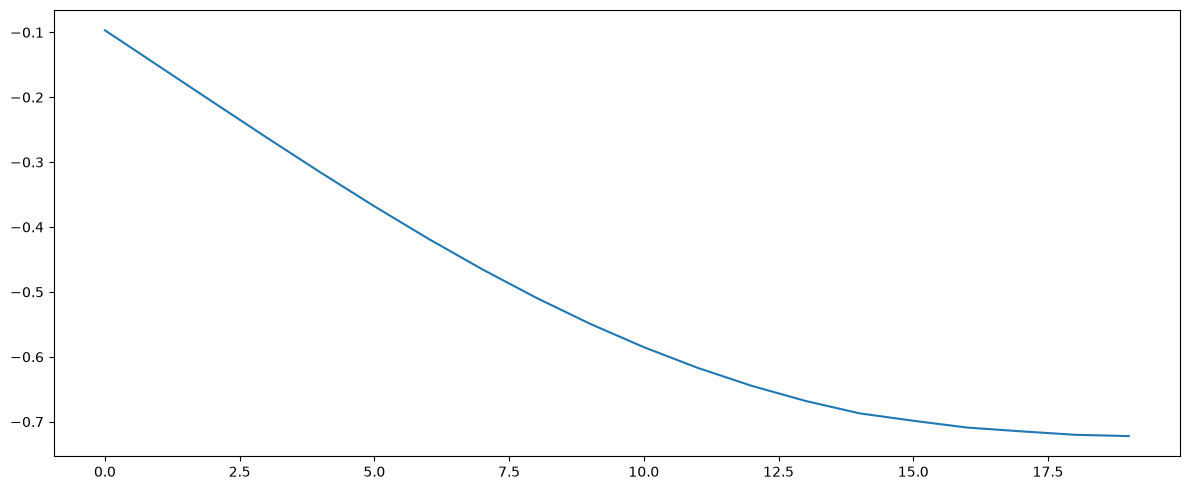

In [6]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 1, figsize=(12, 5))

axs.plot(range(EPOCHS), tr_loss_history)

fig.tight_layout()
plt.show()